<a href="https://colab.research.google.com/github/Siva1212-genious/ML-Algorithms---ScikitLearn/blob/main/RandomForestClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install legacy-cgi --quiet

In [2]:
!pip install opendatasets --quiet

In [3]:
import opendatasets as od
dataset_url = 'https://www.kaggle.com/jsphyg/weather-dataset-rattle-package'

od.download(dataset_url)

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: siva
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package


100%|██████████| 3.83M/3.83M [00:00<00:00, 160MB/s]

In [4]:
import os

data_dir = './weather-dataset-rattle-package'

os.listdir(data_dir)

['weatherAUS.csv']

In [5]:
data = data_dir + '/weatherAUS.csv'

data

'./weather-dataset-rattle-package/weatherAUS.csv'

In [6]:
import pandas as pd

data_set = pd.read_csv(data)

data_set

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [7]:
#Dividing numeric and categorical columns

In [8]:
import numpy as np

numeric_cols = data_set.select_dtypes(include=np.number).columns.tolist()
categorical_cols = data_set.select_dtypes('object').columns.tolist()

In [9]:
numeric_cols, categorical_cols

(['MinTemp',
  'MaxTemp',
  'Rainfall',
  'Evaporation',
  'Sunshine',
  'WindGustSpeed',
  'WindSpeed9am',
  'WindSpeed3pm',
  'Humidity9am',
  'Humidity3pm',
  'Pressure9am',
  'Pressure3pm',
  'Cloud9am',
  'Cloud3pm',
  'Temp9am',
  'Temp3pm'],
 ['Date',
  'Location',
  'WindGustDir',
  'WindDir9am',
  'WindDir3pm',
  'RainToday',
  'RainTomorrow'])

In [10]:
import pandas as pd
date_dataset = pd.to_datetime(data_set.Date).dt.year


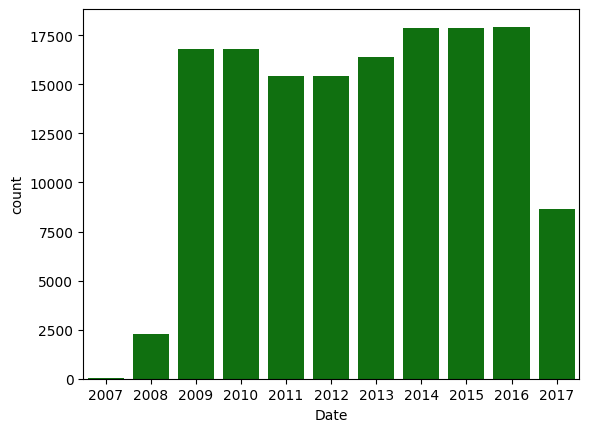

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=pd.to_datetime(data_set.Date).dt.year, color = 'green');
plt.show()

In [12]:
from sklearn.impute import SimpleImputer
import numpy as np

# Re-define numeric_cols to ensure it's a list of column names
numeric_cols = data_set.select_dtypes(include=np.number).columns.tolist()

imputer = SimpleImputer(strategy='mean')

data_set[numeric_cols] = imputer.fit_transform(data_set[numeric_cols])

In [13]:
data_set.isna().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,10326
WindGustSpeed,0
WindDir9am,10566


In [14]:
data_set[categorical_cols] = data_set[categorical_cols].fillna('unknown')

In [15]:
data_set.isna().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


In [16]:
data_set = data_set[data_set['RainToday'] != 'unknown']

In [17]:
data_set = data_set[data_set['RainTomorrow'] != 'unknown']

In [18]:
data_set[data_set['RainTomorrow'] == 'unknown']

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow


In [19]:
input_cols = list(data_set.columns[1:-1])
target_cols = 'RainTomorrow'

In [20]:
input_cols, target_cols

(['Location',
  'MinTemp',
  'MaxTemp',
  'Rainfall',
  'Evaporation',
  'Sunshine',
  'WindGustDir',
  'WindGustSpeed',
  'WindDir9am',
  'WindDir3pm',
  'WindSpeed9am',
  'WindSpeed3pm',
  'Humidity9am',
  'Humidity3pm',
  'Pressure9am',
  'Pressure3pm',
  'Cloud9am',
  'Cloud3pm',
  'Temp9am',
  'Temp3pm',
  'RainToday'],
 'RainTomorrow')

In [21]:
numeric_cols = data_set[input_cols].select_dtypes(include = np.number).columns.tolist()
categorical_cols = data_set[input_cols].select_dtypes('object').columns.tolist()

In [22]:
data_set[categorical_cols]

,Location,WindGustDir,WindDir9am,WindDir3pm,RainToday
0,Albury,W,W,WNW,No
1,Albury,WNW,NNW,WSW,No
2,Albury,WSW,W,WSW,No
3,Albury,NE,SE,E,No
4,Albury,W,ENE,NW,No
...,...,...,...,...,...
145454,Uluru,E,ESE,E,No
145455,Uluru,E,SE,ENE,No
145456,Uluru,NNW,SE,N,No
145457,Uluru,N,SE,WNW,No


In [23]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output = False, handle_unknown='ignore')

encode = encoder.fit(data_set[categorical_cols])

encoded_cols_list = list(encoder.get_feature_names_out(categorical_cols))

data_set[encoded_cols_list] = encoder.transform(data_set[categorical_cols])

/tmp/ipykernel_2818/1795266719.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set[encoded_cols_list] = encoder.transform(data_set[categorical_cols])
/tmp/ipykernel_2818/1795266719.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set[encoded_cols_list] = encoder.transform(data_set[categorical_cols])
/tmp/ipykernel_2818/1795266719.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at 

In [24]:
main_dataset = data_set[numeric_cols + encoded_cols_list]

In [25]:
data_set['RainToday_Yes'].count()

np.int64(140787)

In [26]:
# We have completed the Data-Pre-Processing. Now, we can use this data and we can train our model using random forest

In [27]:
# ------------------------------------------ RANDOM FOREST ------------------------------------------------

In [28]:
# We will split the data using train_test_split

In [29]:
from sklearn.model_selection import train_test_split

X_train_val, test_dt, Y_train_val, test_target = train_test_split(main_dataset, data_set[target_cols], test_size=0.2, random_state=42)

train_dt, val_dt, train_target, val_target = train_test_split(X_train_val, Y_train_val, test_size=0.2, random_state=42)


In [30]:
print(train_dt.shape)
print(val_dt.shape)
print(test_dt.shape)

(90103, 118)
(22526, 118)
(28158, 118)


In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators = 100, criterion = 'gini', random_state=42, bootstrap=True)

In [32]:
model.fit(train_dt, train_target)

train_prediction = model.predict(train_dt)

print("Train_Prediction: ", train_prediction)

Train_Prediction:  ['No' 'No' 'No' ... 'No' 'No' 'No']


In [33]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(train_target, train_prediction)

print("Train_Prediction: ", train_accuracy*100)

Train_Prediction:  99.99334095424126


In [34]:
val_prediction = model.predict(val_dt)

val_accuracy = accuracy_score(val_target, val_prediction)

print("Validation_Prediction: ", val_accuracy*100)

Validation_Prediction:  85.53227381692267


In [35]:
# We can check the importance that is given to the good column. by following method

important_df = pd.DataFrame({
    'feature': train_dt.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending = False)


In [36]:
important_df.head(10)

,feature,importance
9,Humidity3pm,0.132931
11,Pressure3pm,0.052695
4,Sunshine,0.051590
8,Humidity9am,0.050298
10,Pressure9am,0.049976
5,WindGustSpeed,0.048253
2,Rainfall,0.046944
15,Temp3pm,0.045561
1,MaxTemp,0.043696
0,MinTemp,0.043612


<Axes: title={'center': 'Feature Importance'}, xlabel='importance', ylabel='feature'>

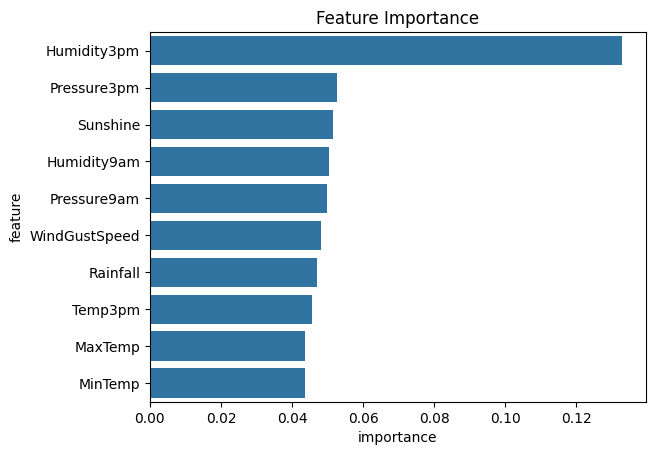

In [37]:
plt.title('Feature Importance')
sns.barplot(data = important_df.head(10), x= 'importance', y= 'feature')

In [38]:
# In Random Forest, n_estimators and max_features plays major role. So, now we will use the
#HyperParameter Tuning to Overcome this problem and we will make the best model.

In [39]:
#for estimate in [20, 40, 50, 60, 80,90,100,120,150,170,190,200]:
 # model_1 = RandomForestClassifier(n_estimators=estimate, criterion='gini', random_state=42, bootstrap=True)
  #model_1.fit(train_dt, train_target)

  #train1_prediction = model_1.score(train_dt, train_target)
  #validation1_prediction = model_1.score(val_dt, val_target)
  #print(estimate, train1_prediction, validation1_prediction)

#We got the best prediction for n_estimaters = 170. but, when n_estimaters = 100 it was good. same as n_estimator=170(almost)
#so, we can keep 100.

In [41]:
# Now we will do for the max_features


#for feature in [5,10,15,20,25,30,35,40,45,50,60,70,80,90,100,110]:
 # model_2 = RandomForestClassifier(n_estimators=100, criterion='gini',
  #                                     max_features = feature, random_state=42, bootstrap=True,
   #                                    n_jobs = -1)
  #model_2.fit(train_dt, train_target)

  #train2_prediction = model_2.score(train_dt, train_target)
  #validation2_prediction = model_2.score(val_dt, val_target)

  #print(feature, train2_prediction, validation2_prediction)

  # SO, the best max_features = 35. here is where we will be getting good model. of 85.83%

In [42]:
#for depth in [4,5, 9, 10, 20, 25, 30, 35, 40, 45, 50, 60,70,80]:
#  model_3 = RandomForestClassifier(n_estimators=100, criterion='gini',
#                                   max_features=35, max_depth = depth,
 #                                  n_jobs=-1, random_state=42, bootstrap=True)
  #model_3.fit(train_dt, train_target)

  #train3_prediction = model_3.score(train_dt, train_target)
  #val3_prediction = model_3.score(val_dt, val_target)

  #print(depth, train3_prediction, val3_prediction)

  #It is giving us best results when max_depth = 50, that is 85.90%

4 0.8392284385647537 0.8381425907839829
5 0.8442227228838107 0.8422711533339252
9 0.8644995172191825 0.850128740122525
10 0.8727900291888172 0.8507502441623014
20 0.9713550048278081 0.8569208914143657
25 0.991853767355138 0.8562549942288911
30 0.9980355815011709 0.8582082926396164
35 0.9997003429408565 0.8586078309509012
40 0.9998890159040209 0.8565657462487792
45 0.9999334095424126 0.8583414720767114
50 0.9999445079520105 0.8590517624078842
60 0.9999445079520105 0.8584302583681079
70 0.9999445079520105 0.8583858652224097
80 0.9999445079520105 0.8583858652224097


In [43]:
#Yes, you can use GridSearchCV or RandomizedSearchCV from sklearn.model_selection to automate the search for the best hyperparameters and extract the feature importances from the best model all at once.
#Instead of writing manual loops, GridSearchCV handles the iterations, tracks the scores, and identifies the optimal configuration automatically.

In [44]:
#from sklearn.model_selection import GridSearchCV
#import pandas as pd

# 1. Define the parameter grid (add other parameters here if you want to test them too)
#param_grid = {
#    'max_depth': [4, 5, 9, 10, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80]
#}

## 2. Initialize the base model with fixed parameters
#base_rf = RandomForestClassifier(
 #   n_estimators=100,
  #  criterion='gini',
   # max_features=35,
   #n_jobs=-1,
   # random_state=42,
   # bootstrap=True
#)

# 3. Set up GridSearchCV (using PredefinedSplit if you have a strict train/val split)
# Note: By default, GridSearchCV uses Cross-Validation.
# To use your exact validation set (val_dt), we can use a PredefinedSplit.
#from sklearn.model_selection import PredefinedSplit
#import numpy as np

# Combine train and validation data for the grid search
#X_combined = np.vstack((train_dt, val_dt))
#y_combined = np.concatenate((train_target, val_target))

# Create a split marker: -1 for train, 0 for validation
#split_index = [-1] * len(train_dt) + [0] * len(val_dt)
#pds = PredefinedSplit(test_fold=split_index)

#grid_search = GridSearchCV(estimator=base_rf, param_grid=param_grid, cv=pds, n_jobs=-1, return_train_score=True)
#grid_search.fit(X_combined, y_combined)

# 4. Extract the best model and parameters
#best_model = grid_search.best_estimator_
#print(f"Best Parameters: {grid_search.best_params_}")
#print(f"Best Validation Score: {grid_search.best_score_}")

# 5. Get all feature importances at once from the best model
#importances = best_model.feature_importances_

# (Optional) Put importances into a clean DataFrame
#feature_names = train_dt.columns if hasattr(train_dt, 'columns') else [f'feature_{i}' for i in range(train_dt.shape[1])]
#importance_df = pd.DataFrame({
#    'Feature': feature_names,
 #   'Importance': importances
#}).sort_values(by='Importance', ascending=False)

#print(importance_df)

In [ ]:
# Now we know the best Hyper Parameters for our model, to perform its best

In [46]:
from sklearn.ensemble import RandomForestClassifier

best_model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42,
                                    max_features=35, max_depth=50, bootstrap=True,
                                    n_jobs = -1)

best_model.fit(train_dt, train_target)

predict_train = best_model.predict(train_dt)

In [48]:
from sklearn.metrics import accuracy_score

train_dt_accuracy = accuracy_score(train_target, predict_train)

print("Train_data_accuracy: ", train_dt_accuracy*100)

Train_data_accuracy:  99.99445079520105


In [49]:
# Now lets predict validation data.

predict_validation = best_model.predict(val_dt)


val_dt_accuracy = accuracy_score(val_target, predict_validation)

print("Validation_data_accuracy: ", val_dt_accuracy*100)


Validation_data_accuracy:  85.90517624078842


In [51]:
# Now lets predict Test data

predict_test = best_model.predict(test_dt)

test_dt_accuracy = accuracy_score(test_target, predict_test)

print("Test_data_accuracy: ", test_dt_accuracy*100)

Test_data_accuracy:  85.5316428723631


In [ ]:
# Now see most of our train_data, val_data, test_data are accurate!!
# train_prediction = 99.994%
# validation_prediction = 85.905%
#Test_prediction = 85.53%

#Hence, If we improve Hyper Parameters, then we can decrease "Overfitting" and we can make "Best Model"